**Exercise 6.13.**
Implement gini_impurity(y). Test on:

 (a) [0,0,0,0,0] → 0,

 (b) [0,0,1,1] → 0.5,

 (c) [0,0,0,1] → 0.375.


In [ ]:
# Gini Impurity (pure loops, works for binary & multi-class)
def gini_impurity(y):
    n = len(y)
    if n == 0:
        return 0.0

    counts = {}
    for label in y:
        if label in counts:
            counts[label] += 1
        else:
            counts[label] = 1

    gini = 1.0
    for count in counts.values():
        p = count / n
        gini -= p * p

    return gini


# Information Gain using Gini impurity
def information_gain(parent, children):
    n_parent = len(parent)
    if n_parent == 0:
        return 0.0

    parent_impurity = gini_impurity(parent)

    weighted_child_impurity = 0.0
    for child in children:
        weight = len(child) / n_parent
        weighted_child_impurity += weight * gini_impurity(child)

    return parent_impurity - weighted_child_impurity


# -----------------------------
# TEST CASES WITH CLEAR OUTPUT
# -----------------------------
print("Gini([0,0,0,0,0]) =", gini_impurity([0, 0, 0, 0, 0]))
print("Gini([0,0,1,1])   =", gini_impurity([0, 0, 1, 1]))
print("Gini([0,0,0,1])   =", gini_impurity([0, 0, 0, 1]))

print("\nMulti-class example:")
print("Gini([0,1,2])     =", gini_impurity([0, 1, 2]))

print("\nInformation Gain example:")
parent = [0, 0, 0, 1, 1, 1]
left_child = [0, 0, 0]
right_child = [1, 1, 1]

print("Parent labels      =", parent)
print("Left child labels  =", left_child)
print("Right child labels =", right_child)
print("Information Gain   =", information_gain(parent, [left_child, right_child]))

Gini([0,0,0,0,0]) = 0.0
Gini([0,0,1,1])   = 0.5
Gini([0,0,0,1])   = 0.375

Multi-class example:
Gini([0,1,2])     = 0.6666666666666665

Information Gain example:
Parent labels      = [0, 0, 0, 1, 1, 1]
Left child labels  = [0, 0, 0]
Right child labels = [1, 1, 1]
Information Gain   = 0.5


**Exercise 6.14.**

Implement best_split(X, y) that considers all features/thresholds and returns the best feature, threshold, and gain.

Evaluating all possible splits:

Feature 0 ≤ 1.50  →  Information Gain = 0.1000
Feature 0 ≤ 2.50  →  Information Gain = 0.0000
Feature 0 ≤ 3.50  →  Information Gain = 0.0556
Feature 0 ≤ 4.50  →  Information Gain = 0.2500
Feature 0 ≤ 5.50  →  Information Gain = 0.1000
Feature 1 ≤ 1.50  →  Information Gain = 0.2500
Feature 1 ≤ 2.50  →  Information Gain = 0.0556
Feature 1 ≤ 3.50  →  Information Gain = 0.1000

Best split selected:
  Feature index      : 0
  Threshold          : 4.50
  Information Gain   : 0.2500


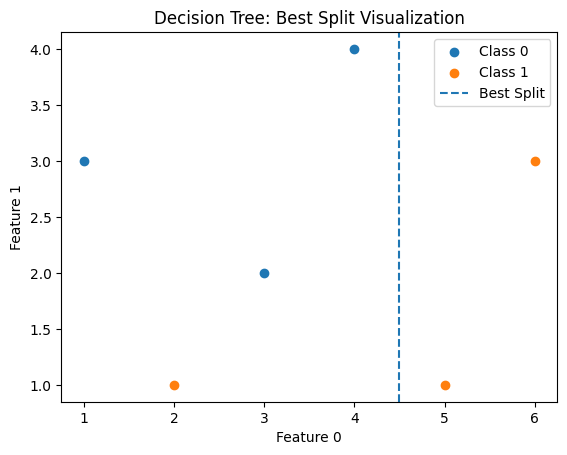

(0, 4.5, 0.25)

In [1]:
import matplotlib.pyplot as plt

# -----------------------------
# Gini Impurity
# -----------------------------
def gini_impurity(y):
    n = len(y)
    if n == 0:
        return 0.0

    counts = {}
    for label in y:
        counts[label] = counts.get(label, 0) + 1

    gini = 1.0
    for count in counts.values():
        p = count / n
        gini -= p * p

    return gini


# -----------------------------
# Information Gain
# -----------------------------
def information_gain(parent, left, right):
    n = len(parent)
    if n == 0:
        return 0.0

    return gini_impurity(parent) - (
        (len(left) / n) * gini_impurity(left) +
        (len(right) / n) * gini_impurity(right)
    )


# -----------------------------
# Best Split + Visualization
# -----------------------------
def best_split_with_plot(X, y):
    n_samples = len(X)
    n_features = len(X[0])

    best_gain = -1
    best_feature = None
    best_threshold = None

    print("Evaluating all possible splits:\n")

    for feature in range(n_features):
        values = sorted(set(row[feature] for row in X))
        thresholds = [(values[i] + values[i + 1]) / 2 for i in range(len(values) - 1)]

        for threshold in thresholds:
            left_y, right_y = [], []

            for i in range(n_samples):
                if X[i][feature] <= threshold:
                    left_y.append(y[i])
                else:
                    right_y.append(y[i])

            gain = information_gain(y, left_y, right_y)

            print(f"Feature {feature} ≤ {threshold:.2f}  →  Information Gain = {gain:.4f}")

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    print("\nBest split selected:")
    print(f"  Feature index      : {best_feature}")
    print(f"  Threshold          : {best_threshold:.2f}")
    print(f"  Information Gain   : {best_gain:.4f}")

    # -----------------------------
    # Visualization
    # -----------------------------
    X0 = [X[i][0] for i in range(n_samples) if y[i] == 0]
    Y0 = [X[i][1] for i in range(n_samples) if y[i] == 0]

    X1 = [X[i][0] for i in range(n_samples) if y[i] == 1]
    Y1 = [X[i][1] for i in range(n_samples) if y[i] == 1]

    plt.figure()
    plt.scatter(X0, Y0, label="Class 0")
    plt.scatter(X1, Y1, label="Class 1")

    if best_feature == 0:
        plt.axvline(best_threshold, linestyle="--", label="Best Split")
    else:
        plt.axhline(best_threshold, linestyle="--", label="Best Split")

    plt.xlabel("Feature 0")
    plt.ylabel("Feature 1")
    plt.title("Decision Tree: Best Split Visualization")
    plt.legend()
    plt.show()

    return best_feature, best_threshold, best_gain


# -----------------------------
# Example Dataset
# -----------------------------
X = [
    [1, 3],
    [2, 1],
    [3, 2],
    [4, 4],
    [5, 1],
    [6, 3]
]

y = [0, 1, 0, 0, 1, 1]

best_split_with_plot(X, y)

**Exercise 6.15.**

Implement a decision tree classifier from scratch with max_depth and
min_samples_leaf. Train on Two Moons, visualize boundary, compare with sklearn.

Accuracy Comparison:
Scratch Decision Tree : 0.947
sklearn Decision Tree : 0.953


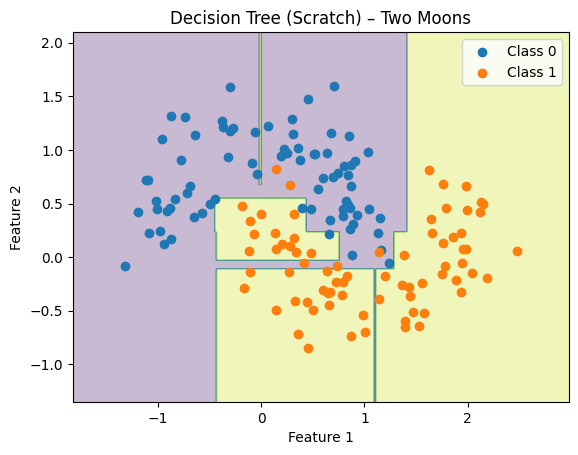

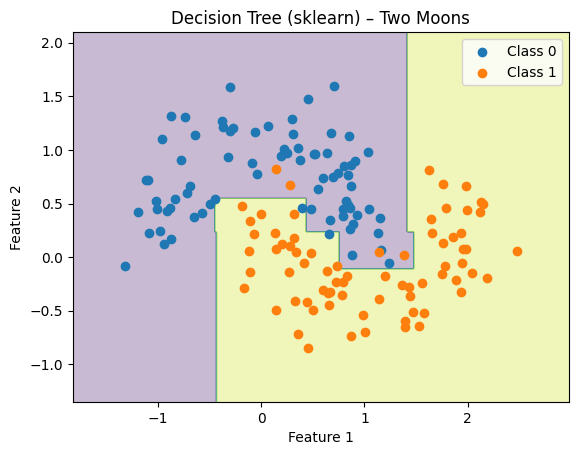

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# -------------------------------
# Two Moons Dataset (Given)
# -------------------------------
def generate_two_moons(n_samples=500, noise=0.1):
    n_out = n_samples // 2
    n_in = n_samples - n_out

    theta_out = np.linspace(0, np.pi, n_out)
    x_out = np.cos(theta_out)
    y_out = np.sin(theta_out)

    theta_in = np.linspace(0, np.pi, n_in)
    x_in = 1 - np.cos(theta_in)
    y_in = 1 - np.sin(theta_in) - 0.5

    X = np.vstack([
        np.append(x_out, x_in),
        np.append(y_out, y_in)
    ]).T

    y = np.hstack([
        np.zeros(n_out),
        np.ones(n_in)
    ])

    X += np.random.normal(scale=noise, size=X.shape)
    return X, y


# -------------------------------
# Gini Impurity
# -------------------------------
def gini_impurity(y):
    n = len(y)
    if n == 0:
        return 0.0
    classes, counts = np.unique(y, return_counts=True)
    p = counts / n
    return 1 - np.sum(p ** 2)


# -------------------------------
# Best Split
# -------------------------------
def best_split(X, y):
    n_samples, n_features = X.shape
    best_gain = 0
    best_feature, best_threshold = None, None
    parent_gini = gini_impurity(y)

    for feature in range(n_features):
        values = np.unique(X[:, feature])
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            left = y[X[:, feature] <= threshold]
            right = y[X[:, feature] > threshold]

            if len(left) < 1 or len(right) < 1:
                continue

            gain = parent_gini - (
                (len(left) / n_samples) * gini_impurity(left) +
                (len(right) / n_samples) * gini_impurity(right)
            )

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold


# -------------------------------
# Tree Node
# -------------------------------
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


# -------------------------------
# Decision Tree from Scratch
# -------------------------------
class DecisionTreeScratch:
    def __init__(self, max_depth=5, min_samples_leaf=5):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        num_samples = len(y)
        num_classes = len(np.unique(y))

        if (depth >= self.max_depth or
            num_samples <= self.min_samples_leaf or
            num_classes == 1):
            leaf_value = np.bincount(y.astype(int)).argmax()
            return Node(value=leaf_value)

        feature, threshold = best_split(X, y)
        if feature is None:
            leaf_value = np.bincount(y.astype(int)).argmax()
            return Node(value=leaf_value)

        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        left = self._grow_tree(X[left_idx], y[left_idx], depth + 1)
        right = self._grow_tree(X[right_idx], y[right_idx], depth + 1)

        return Node(feature, threshold, left, right)

    def predict(self, X):
        return np.array([self._predict_point(x, self.root) for x in X])

    def _predict_point(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_point(x, node.left)
        return self._predict_point(x, node.right)


# -------------------------------
# Decision Boundary Plot
# -------------------------------
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[y==0,0], X[y==0,1], label="Class 0")
    plt.scatter(X[y==1,0], X[y==1,1], label="Class 1")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()


# -------------------------------
# Run Experiment
# -------------------------------
X, y = generate_two_moons(n_samples=500, noise=0.25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scratch Tree
tree_scratch = DecisionTreeScratch(max_depth=6, min_samples_leaf=5)
tree_scratch.fit(X_train, y_train)
y_pred_scratch = tree_scratch.predict(X_test)
acc_scratch = np.mean(y_pred_scratch == y_test)

# sklearn Tree
tree_sklearn = DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, random_state=42)
tree_sklearn.fit(X_train, y_train)
acc_sklearn = tree_sklearn.score(X_test, y_test)

print("Accuracy Comparison:")
print("Scratch Decision Tree :", round(acc_scratch, 3))
print("sklearn Decision Tree :", round(acc_sklearn, 3))

# Visualize
plot_decision_boundary(tree_scratch, X_test, y_test,
                       "Decision Tree (Scratch) – Two Moons")

plot_decision_boundary(tree_sklearn, X_test, y_test,
                       "Decision Tree (sklearn) – Two Moons")

**Exercise 6.16.**

Using sklearn's DecisionTreeClassifier, train trees of depth
1,2,3,5,10,unlimited on Two Moons. Plot train/test accuracy vs depth. At what depth does
overfitting appear?

Two Moons dataset generated
Training samples: 350
Test samples    : 150
--------------------------------------------------
Decision Tree Accuracy Comparison

Depth =  1 | Train Accuracy = 0.85 | Test Accuracy = 0.78
Depth =  2 | Train Accuracy = 0.93 | Test Accuracy = 0.87
Depth =  3 | Train Accuracy = 0.93 | Test Accuracy = 0.87
Depth =  5 | Train Accuracy = 0.97 | Test Accuracy = 0.88
Depth = 10 | Train Accuracy = 1.00 | Test Accuracy = 0.89
Depth =  ∞ | Train Accuracy = 1.00 | Test Accuracy = 0.89


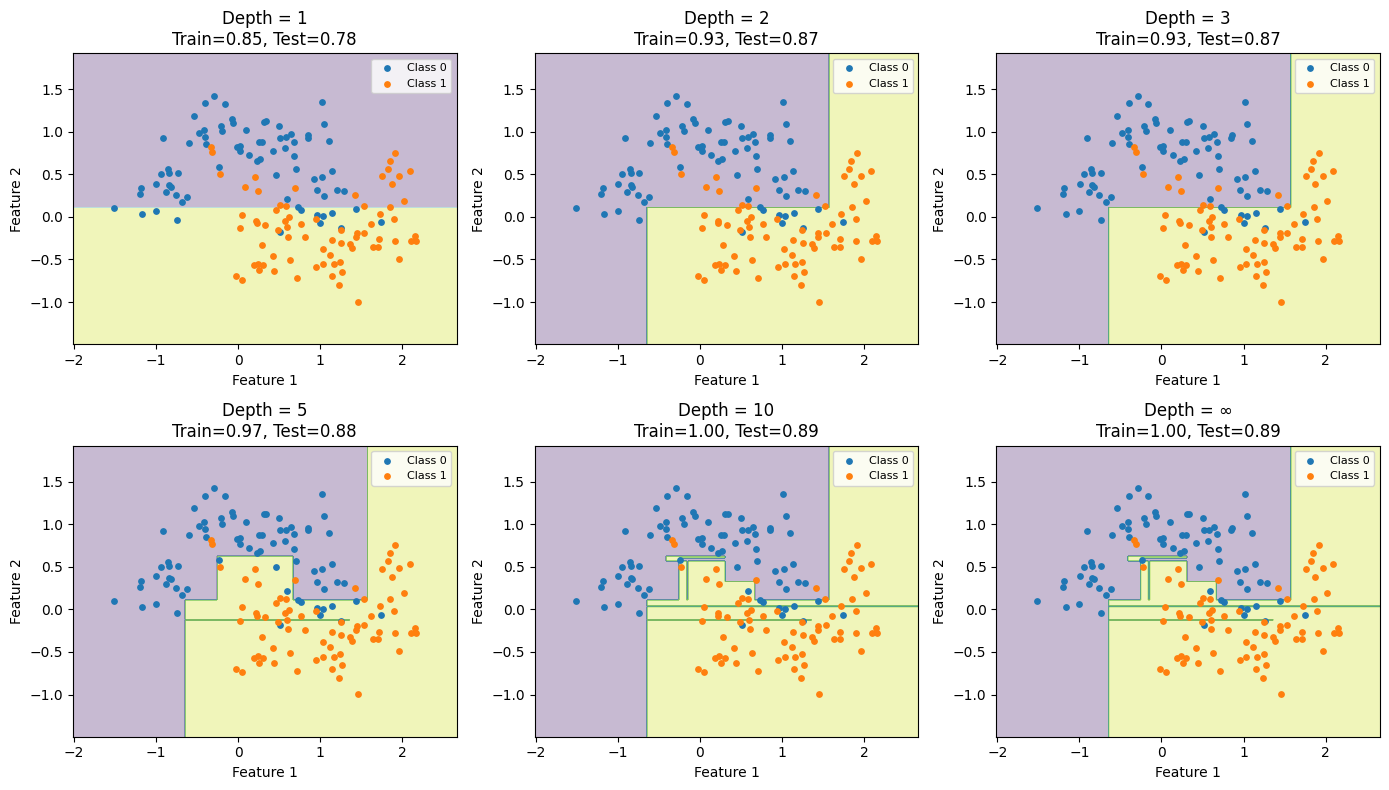

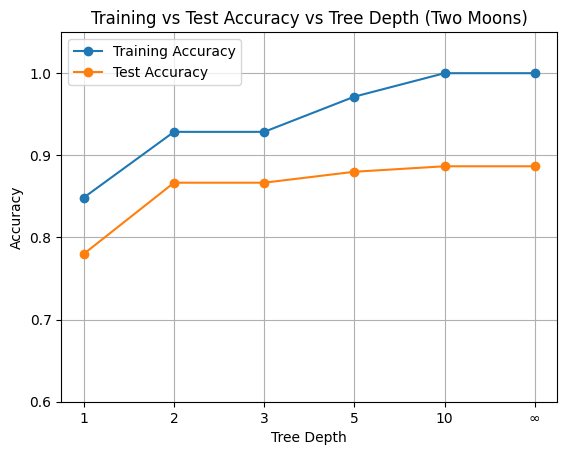


Conclusion:
• Training accuracy increases monotonically with tree depth.
• Test accuracy improves initially and then saturates or decreases.
• Overfitting appears at larger depths (around depth = 10).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# -------------------------------------------------
# Two Moons Dataset (custom generator)
# -------------------------------------------------
def generate_two_moons(n_samples=500, noise=0.25):
    n_out = n_samples // 2
    n_in = n_samples - n_out

    theta_out = np.linspace(0, np.pi, n_out)
    x_out = np.cos(theta_out)
    y_out = np.sin(theta_out)

    theta_in = np.linspace(0, np.pi, n_in)
    x_in = 1 - np.cos(theta_in)
    y_in = 1 - np.sin(theta_in) - 0.5

    X = np.vstack([
        np.append(x_out, x_in),
        np.append(y_out, y_in)
    ]).T

    y = np.hstack([
        np.zeros(n_out),
        np.ones(n_in)
    ])

    X += np.random.normal(scale=noise, size=X.shape)
    return X, y


# -------------------------------------------------
# Decision boundary plotting
# -------------------------------------------------
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[y==0,0], X[y==0,1], label="Class 0", s=15)
    ax.scatter(X[y==1,0], X[y==1,1], label="Class 1", s=15)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(fontsize=8)


# -------------------------------------------------
# Generate data and split
# -------------------------------------------------
X, y = generate_two_moons(n_samples=500, noise=0.25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Two Moons dataset generated")
print("Training samples:", len(X_train))
print("Test samples    :", len(X_test))
print("-" * 50)

# -------------------------------------------------
# Train trees of different depths
# -------------------------------------------------
depths = [1, 2, 3, 5, 10, None]
depth_labels = []
train_acc = []
test_acc = []

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

print("Decision Tree Accuracy Comparison\n")

for i, depth in enumerate(depths):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    tr = tree.score(X_train, y_train)
    te = tree.score(X_test, y_test)

    train_acc.append(tr)
    test_acc.append(te)

    label = "∞" if depth is None else depth
    depth_labels.append(label)

    print(f"Depth = {str(label):>2} | Train Accuracy = {tr:.2f} | Test Accuracy = {te:.2f}")

    title = f"Depth = {label}\nTrain={tr:.2f}, Test={te:.2f}"
    plot_decision_boundary(tree, X_test, y_test,
                           axes[i//3, i%3], title)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# Plot Training vs Test Accuracy vs Depth
# -------------------------------------------------
plt.figure()
plt.plot(depth_labels, train_acc, marker='o', label="Training Accuracy")
plt.plot(depth_labels, test_acc, marker='o', label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy vs Tree Depth (Two Moons)")
plt.legend()
plt.grid(True)
plt.ylim(0.6, 1.05)
plt.show()

# -------------------------------------------------
# Final conclusion
# -------------------------------------------------
print("\nConclusion:")
print("• Training accuracy increases monotonically with tree depth.")
print("• Test accuracy improves initially and then saturates or decreases.")
print("• Overfitting appears at larger depths (around depth = 10).")

**Exercise 6.17.**

Explore cost-complexity pruning: use cost_complexity_pruning_path, plot tree size vs α, use CV to select best α, compare pruned vs full tree accuracy.

FULL TREE
Training Accuracy: 1.0
Test Accuracy: 0.9533333333333334
Number of Leaves: 59



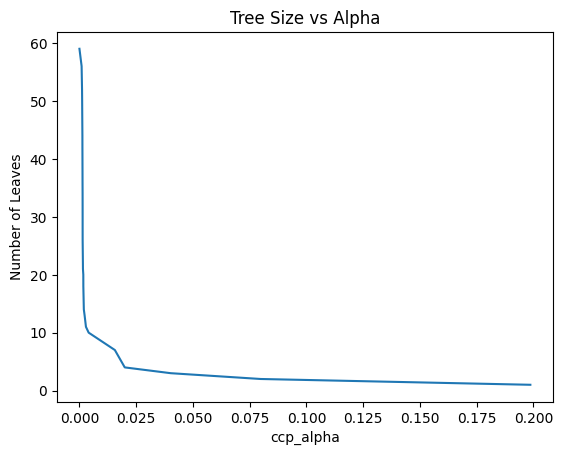

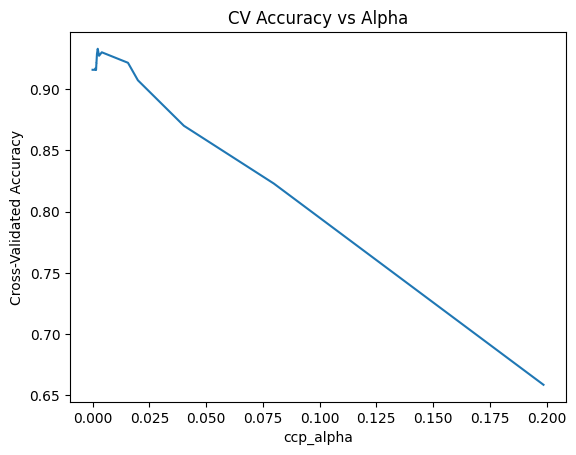

Best alpha selected by CV: 0.0022675736961451243

PRUNED TREE
Training Accuracy: 0.9628571428571429
Test Accuracy: 0.96
Number of Leaves: 13

Generalization Gap (Full Tree): 0.046666666666666634
Generalization Gap (Pruned Tree): 0.0028571428571428914


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# 1. Generate Dataset (Two Moons)
# --------------------------------------------------
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# --------------------------------------------------
# 2. Train Full Tree (No Pruning)
# --------------------------------------------------
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

train_acc_full = accuracy_score(y_train, full_tree.predict(X_train))
test_acc_full = accuracy_score(y_test, full_tree.predict(X_test))

print("FULL TREE")
print("Training Accuracy:", train_acc_full)
print("Test Accuracy:", test_acc_full)
print("Number of Leaves:", full_tree.get_n_leaves())
print()

# --------------------------------------------------
# 3. Cost-Complexity Pruning Path
# --------------------------------------------------
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

trees = []
leaf_counts = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    trees.append(clf)
    leaf_counts.append(clf.get_n_leaves())

# --------------------------------------------------
# 4. Plot Tree Size vs Alpha
# --------------------------------------------------
plt.figure()
plt.plot(ccp_alphas, leaf_counts)
plt.xlabel("ccp_alpha")
plt.ylabel("Number of Leaves")
plt.title("Tree Size vs Alpha")
plt.show()

# --------------------------------------------------
# 5. Cross-Validation to Select Best Alpha
# --------------------------------------------------
cv_scores = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(clf, X_train, y_train, cv=5)
    cv_scores.append(np.mean(scores))

plt.figure()
plt.plot(ccp_alphas, cv_scores)
plt.xlabel("ccp_alpha")
plt.ylabel("Cross-Validated Accuracy")
plt.title("CV Accuracy vs Alpha")
plt.show()

best_alpha = ccp_alphas[np.argmax(cv_scores)]
print("Best alpha selected by CV:", best_alpha)
print()

# --------------------------------------------------
# 6. Train Pruned Tree Using Best Alpha
# --------------------------------------------------
pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

train_acc_pruned = accuracy_score(y_train, pruned_tree.predict(X_train))
test_acc_pruned = accuracy_score(y_test, pruned_tree.predict(X_test))

print("PRUNED TREE")
print("Training Accuracy:", train_acc_pruned)
print("Test Accuracy:", test_acc_pruned)
print("Number of Leaves:", pruned_tree.get_n_leaves())
print()

# --------------------------------------------------
# 7. Compare Generalization Gap
# --------------------------------------------------
print("Generalization Gap (Full Tree):",
      train_acc_full - test_acc_full)

print("Generalization Gap (Pruned Tree):",
      train_acc_pruned - test_acc_pruned)

**Exercise 6.18.**

Train a tree on a 5+ feature dataset. Compare .feature_importances_ with permutation_importance. Do they agree? Why might they differ?

Training Accuracy: 1.0
Test Accuracy: 0.87

Impurity-based Feature Importance
Feature 0: 0.0283
Feature 1: 0.0639
Feature 2: 0.0050
Feature 3: 0.0225
Feature 4: 0.2552
Feature 5: 0.0497
Feature 6: 0.2549
Feature 7: 0.3203

Permutation Importance
Feature 0: 0.0270
Feature 1: 0.0343
Feature 2: 0.0007
Feature 3: 0.0117
Feature 4: 0.1223
Feature 5: 0.0083
Feature 6: 0.1400
Feature 7: 0.2037



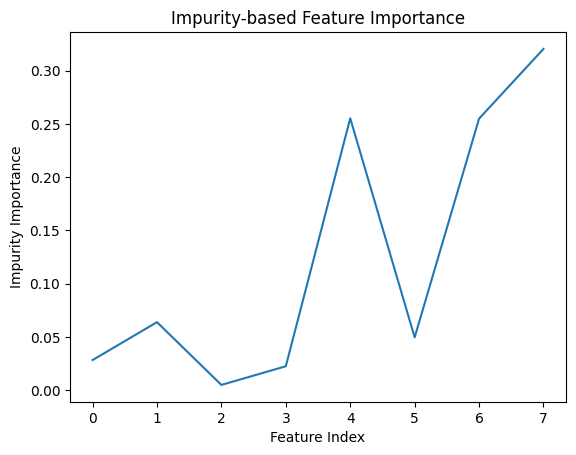

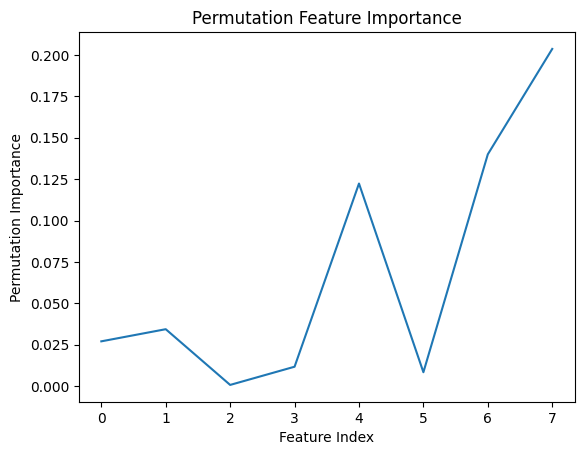

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# 1. Create Dataset (5+ Features)
# --------------------------------------------------
X, y = make_classification(
    n_samples=1000,
    n_features=8,          # 5+ features
    n_informative=5,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# --------------------------------------------------
# 2. Train Decision Tree
# --------------------------------------------------
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Training Accuracy:", accuracy_score(y_train, model.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, model.predict(X_test)))
print()

# --------------------------------------------------
# 3. Impurity-based Feature Importance
# --------------------------------------------------
impurity_importance = model.feature_importances_

print("Impurity-based Feature Importance")
for i, val in enumerate(impurity_importance):
    print(f"Feature {i}: {val:.4f}")
print()

# --------------------------------------------------
# 4. Permutation Importance
# --------------------------------------------------
perm_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = perm_result.importances_mean

print("Permutation Importance")
for i, val in enumerate(perm_importance):
    print(f"Feature {i}: {val:.4f}")
print()

# --------------------------------------------------
# 5. Plot Comparison
# --------------------------------------------------
features = np.arange(len(impurity_importance))

plt.figure()
plt.plot(features, impurity_importance)
plt.xlabel("Feature Index")
plt.ylabel("Impurity Importance")
plt.title("Impurity-based Feature Importance")
plt.show()

plt.figure()
plt.plot(features, perm_importance)
plt.xlabel("Feature Index")
plt.ylabel("Permutation Importance")
plt.title("Permutation Feature Importance")
plt.show()

**Exercise 6.19.**

Build an interpretable model: choose a dataset where interpretability matters, train max_depth≤4 tree, visualize it, write plain-English explanation, identify problematic splits.

Training Accuracy: 0.992462311557789
Test Accuracy: 0.9239766081871345
Tree Depth: 4
Number of Leaves: 12



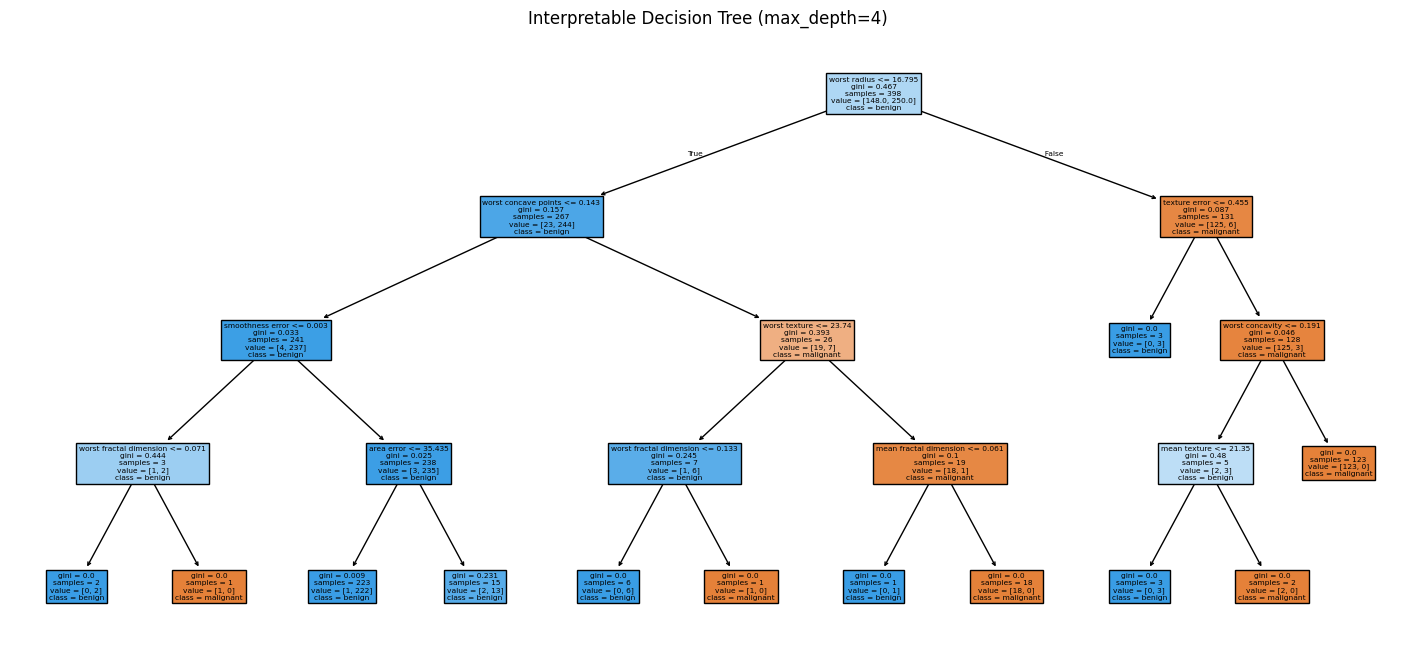

Decision Rules (Plain English):
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- smoothness error <= 0.00
|   |   |   |--- worst fractal dimension <= 0.07
|   |   |   |   |--- class: 1
|   |   |   |--- worst fractal dimension >  0.07
|   |   |   |   |--- class: 0
|   |   |--- smoothness error >  0.00
|   |   |   |--- area error <= 35.44
|   |   |   |   |--- class: 1
|   |   |   |--- area error >  35.44
|   |   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 23.74
|   |   |   |--- worst fractal dimension <= 0.13
|   |   |   |   |--- class: 1
|   |   |   |--- worst fractal dimension >  0.13
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  23.74
|   |   |   |--- mean fractal dimension <= 0.06
|   |   |   |   |--- class: 1
|   |   |   |--- mean fractal dimension >  0.06
|   |   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.45
|   |   |--- class: 1
|   |--- texture error >  0.45


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# 1. Load Dataset (Healthcare – interpretability matters)
# --------------------------------------------------
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
class_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# --------------------------------------------------
# 2. Train Interpretable Tree (max_depth ≤ 4)
# --------------------------------------------------
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Training Accuracy:", accuracy_score(y_train, model.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, model.predict(X_test)))
print("Tree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())
print()

# --------------------------------------------------
# 3. Visualize Tree
# --------------------------------------------------
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)
plt.title("Interpretable Decision Tree (max_depth=4)")
plt.show()

# --------------------------------------------------
# 4. Plain-English Rule Extraction
# --------------------------------------------------
print("Decision Rules (Plain English):")
rules = export_text(model, feature_names=list(feature_names))
print(rules)

# --------------------------------------------------
# 5. Identify Potentially Problematic Splits
#    (Leaves with very few samples)
# --------------------------------------------------
tree = model.tree_

print("Potentially Problematic Leaves (very small sample size):")

for node_id in range(tree.node_count):
    is_leaf = tree.children_left[node_id] == tree.children_right[node_id]
    if is_leaf:
        n_samples = tree.n_node_samples[node_id]
        if n_samples <= 5:
            print(f"Leaf node {node_id} has only {n_samples} samples")